<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Pastor%2C%20L.%2C%20%26%20Veronesi%2C%20P.%20(2009).%20Technological%20revolutions%20and%20stock%20prices/Technological_revolutions_and_stock_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed


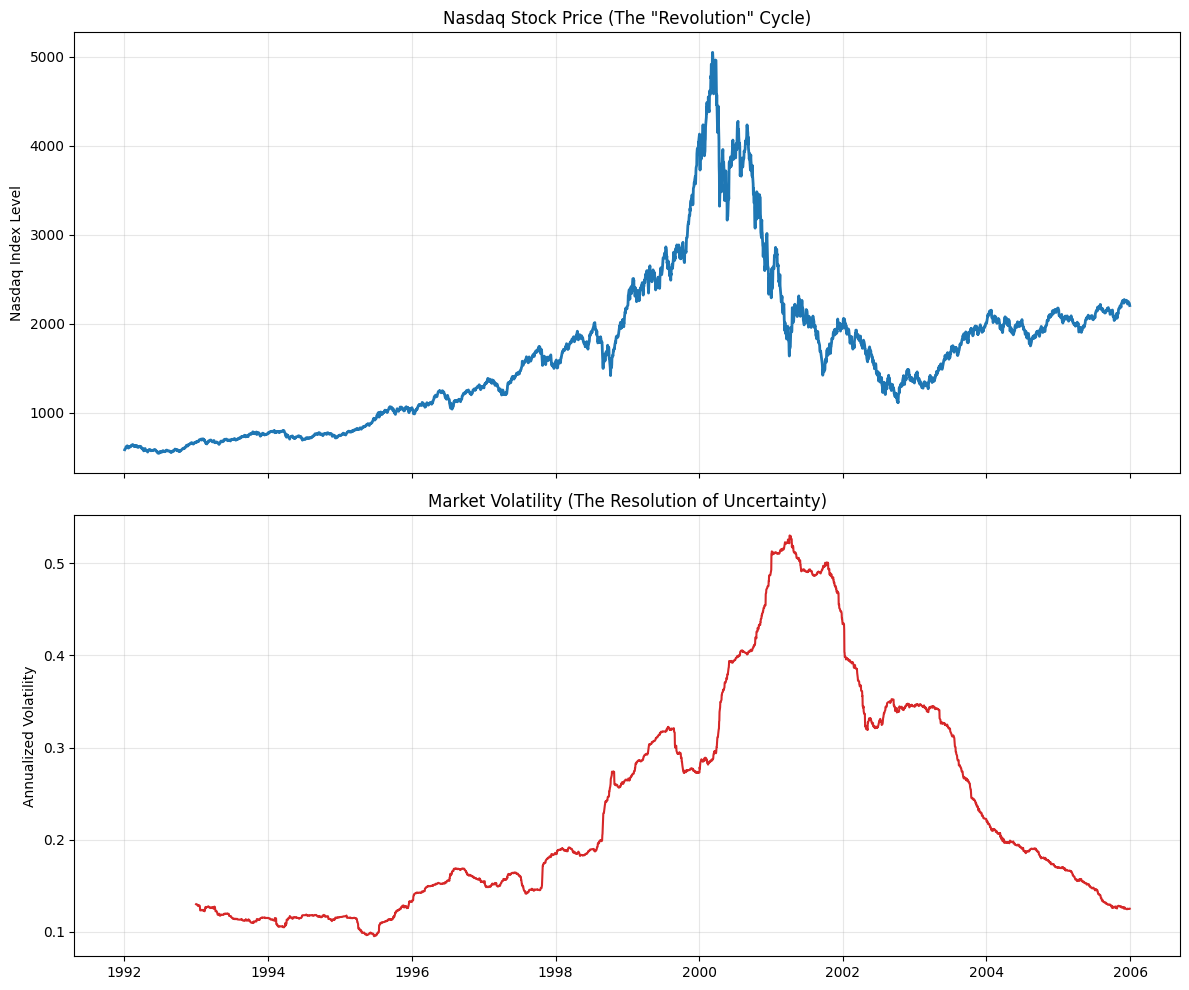

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Fetch historical Nasdaq data
nasdaq = yf.download("^IXIC", start="1992-01-01", end="2005-12-31", auto_adjust=True)

# 2. Calculate Realized Volatility
nasdaq['Returns'] = nasdaq['Close'].pct_change()
nasdaq['Volatility'] = nasdaq['Returns'].rolling(window=252).std() * np.sqrt(252)

# 3. Visualization with Subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top Graph. Price Level
ax1.plot(nasdaq.index, nasdaq['Close'], color='tab:blue', linewidth=2)
ax1.set_ylabel('Nasdaq Index Level')
ax1.set_title('Nasdaq Stock Price (The "Revolution" Cycle)')
ax1.grid(True, alpha=0.3)

# Bottom Graph. Volatility (Uncertainty Proxy)
ax2.plot(nasdaq.index, nasdaq['Volatility'], color='tab:red', linewidth=1.5)
ax2.set_ylabel('Annualized Volatility')
ax2.set_title('Market Volatility (The Resolution of Uncertainty)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The paper argues that the crash happens when this uncertainty is finally resolved. In the graphs, you can see that the market does not just "calm down" when the price falls. Instead, the volatility often reaches extreme levels because the market is suddenly forced to price the technology based on its actual productivity rather than its theoretical "option value."

The relationship is described by the valuation formula$$\frac{P_{t}}{D_{t}} = f(\hat{\theta}_{t}, \hat{\sigma}_{t}^{2})$$In this math, $\hat{\theta}_{t}$ is the estimated productivity and $\hat{\sigma}_{t}^{2}$ is the remaining uncertainty. When the uncertainty $\hat{\sigma}_{t}^{2}$ starts to drop, the "lottery ticket" value of the stock disappears, which can pull the price down even if the technology is still working.

Volatility is a measure of uncertainty or risk in the market.Notice how volatility spikes sharply around 2000, just as the Nasdaq crashes.

[*********************100%***********************]  2 of 2 completed


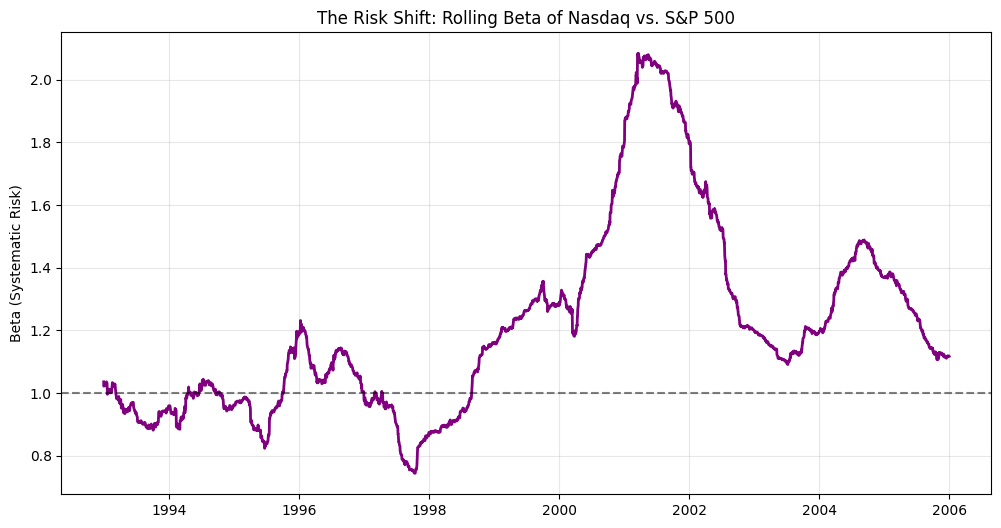

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Fetch Tech (Nasdaq) and Market (S&P 500)
data = yf.download(
    ["^IXIC", "^GSPC"],
    start="1992-01-01",
    end="2005-12-31",
    auto_adjust=False  # matches old default behavior
)['Close']

# Compute daily returns
returns = data.pct_change().dropna()

# Rolling Beta calculation (252 trading days ~ 1 year)
window = 252
covariance = returns['^IXIC'].rolling(window).cov(returns['^GSPC'])
variance = returns['^GSPC'].rolling(window).var()
rolling_beta = covariance / variance

# Plot Rolling Beta
plt.figure(figsize=(12, 6))
plt.plot(rolling_beta, color='purple', linewidth=2)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
plt.title('The Risk Shift: Rolling Beta of Nasdaq vs. S&P 500')
plt.ylabel('Beta (Systematic Risk)')
plt.grid(True, alpha=0.3)
plt.show()

The graph shows the **rolling beta of the Nasdaq relative to the S&P 500** from 1992 to 2005. It illustrates how the Nasdaq’s sensitivity to overall market movements changed over time. When the beta is above 1, Nasdaq was more volatile than the market, and when it’s below 1, it was less volatile. The plot highlights periods of heightened risk, such as the dot-com bubble in the late 1990s and early 2000s, where Nasdaq’s beta spiked well above 1, indicating that tech stocks were significantly more reactive to market swings compared to the broader S&P 500. The horizontal line at beta = 1 serves as a reference for market-level risk.


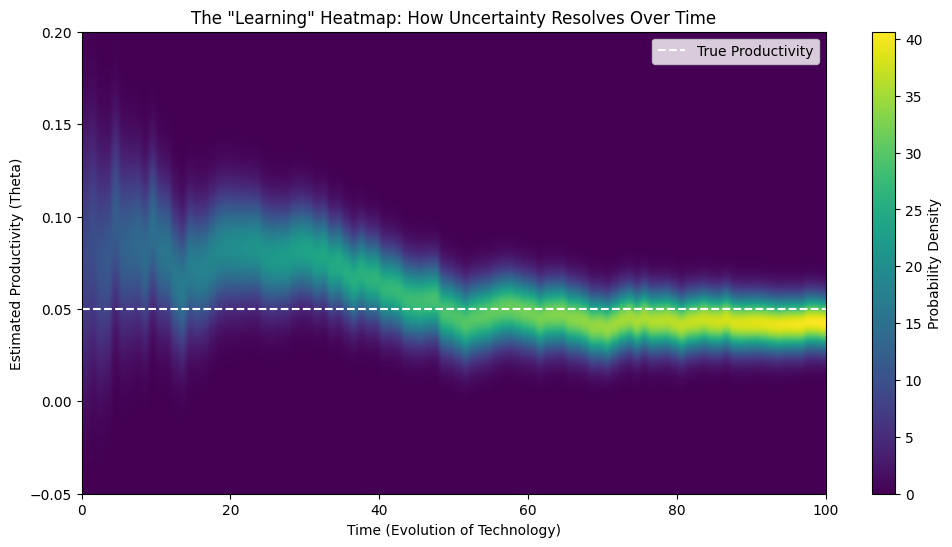

In [7]:
import scipy.stats as stats

# Parameters
T = 100
true_theta = 0.05
prior_mean = 0.09
prior_sd = 0.05
sigma = 0.1  # Noise in the data

# Simulate data and learning
beliefs_over_time = []
current_mean = prior_mean
current_var = prior_sd**2

# Range for the heatmap (the X-axis of the bell curves)
x_range = np.linspace(-0.05, 0.20, 200)

for t in range(T):
    # Observe data
    observation = true_theta + np.random.normal(0, sigma)

    # Update Bayesian belief
    kalman_gain = current_var / (current_var + sigma**2)
    current_mean = current_mean + kalman_gain * (observation - current_mean)
    current_var = (1 - kalman_gain) * current_var

    # Store the bell curve (PDF) for this time step
    pdf = stats.norm.pdf(x_range, current_mean, np.sqrt(current_var))
    beliefs_over_time.append(pdf)

# Convert to a matrix for the heatmap
beliefs_matrix = np.array(beliefs_over_time).T

plt.figure(figsize=(12, 6))
plt.imshow(beliefs_matrix, aspect='auto', extent=[0, T, -0.05, 0.20], origin='lower', cmap='viridis')
plt.axhline(y=true_theta, color='white', linestyle='--', label='True Productivity')
plt.colorbar(label='Probability Density')
plt.title('The "Learning" Heatmap: How Uncertainty Resolves Over Time')
plt.xlabel('Time (Evolution of Technology)')
plt.ylabel('Estimated Productivity (Theta)')
plt.legend()
plt.show()

The paper explains the price $P_t$ as a function of the expected growth and the uncertainty. If we simplify their stochastic discount factor, the valuation multiple looks like this$$\frac{P_t}{D_t} = E_t \left[ \int_{t}^{T} e^{-\rho(s-t) + \theta_s} ds \right]$$In this equation, the stock price is convex with respect to the uncertainty about $\theta$. The "potential" for the technology to be amazing outweighs the risk, leading to a massive valuation multiple during periods of high uncertainty. Once the market realizes the technology is "just okay" (even if it is successful), the variance drops, reflecting a resolution of expectations. Because of that convexity, a drop in variance then leads to a sharp drop in price, resulting in a crash.

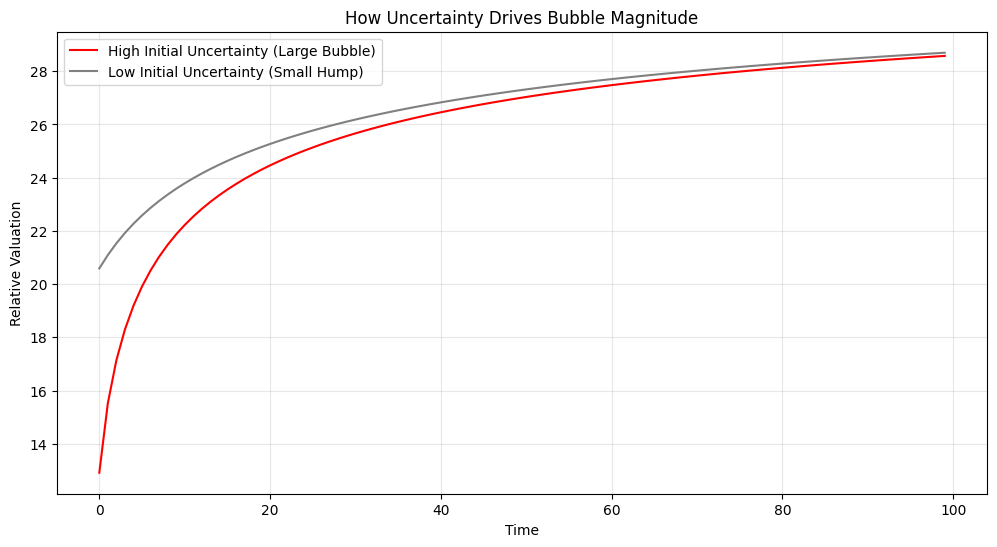

In [5]:
def simulate_bubble(initial_uncertainty):
    # (Simplified version of the logic used previously)
    T = 100
    prior_sd = initial_uncertainty
    sigma = 0.05
    true_theta = 0.05
    prior_mean = 0.08

    # Bayesian Learning
    post_stds = []
    current_var = prior_sd**2
    for t in range(T):
        kalman_gain = current_var / (current_var + sigma**2)
        current_var = (1 - kalman_gain) * current_var
        post_stds.append(np.sqrt(current_var))

    # Simple Price Proxy: Price = 1 / (Rate + Uncertainty)
    prices = [1 / (0.03 + s) for s in post_stds]
    return prices

high_uncertainty = simulate_bubble(0.15)
low_uncertainty = simulate_bubble(0.02)

plt.figure(figsize=(12, 6))
plt.plot(high_uncertainty, label='High Initial Uncertainty (Large Bubble)', color='red')
plt.plot(low_uncertainty, label='Low Initial Uncertainty (Small Hump)', color='gray')
plt.title('How Uncertainty Drives Bubble Magnitude')
plt.ylabel('Relative Valuation')
plt.xlabel('Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The Option Value EquationThe reason these graphs behave this way is rooted in the convexity of the firm's value. The paper shows that the stock price $V_t$ is a convex function of the unknown productivity $\theta$. According to Jensen's Inequality, if a function is convex, the expected value of the function increases when the variance of the input increases. $$E[V(\theta)] \ge V(E[\theta])$$Why the Price CrashesAs the "Revolution" progresses, investors observe the technology in action. The variance $\sigma^2$ of their beliefs decreases (they become more certain). Because the price is convex in relation to uncertainty, the "Option Value" of the technology collapses as the uncertainty disappears. The stock price falls toward its fundamental "Certainty" value, even if the technology is actually successful.